In [36]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
PREDICTORS_DIR_PATH = os.path.join(DATA_DIR_PATH, "predictors")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_run_2025-01-14T17;04;06.975301_output_database")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [5]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v3.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_40_pij_lndu_grasslands+,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,total_positive_emissions,total_negative_emissions
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.289038,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,898.896088,-329.706438
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.536533,0.385371,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,641.742705,-232.744433
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.533412,0.601590,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,394.675852,-334.428479
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.264120,0.938985,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,755.876824,-314.675683
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.430582,0.492564,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,628.746867,-360.795994


In [6]:
# Set some parameters
use_pca = False

## EDA

In [7]:
edau = EDAUtils()

In [8]:
emission_cols = [col for col in training_df.columns if "emissions" in col]
emission_cols

['total_positive_emissions', 'total_negative_emissions']

In [9]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
# lhs_group_cols

In [10]:
training_df[emission_cols].describe()

,total_positive_emissions,total_negative_emissions
count,9.840000e+02,984.000000
mean,1.049032e+06,-327.527643
std,1.452469e+07,48.369751
min,3.946759e+02,-445.411052
25%,6.230989e+02,-362.901701
50%,7.064039e+02,-326.815264
75%,8.164778e+02,-292.308397
max,3.037559e+08,-214.071578


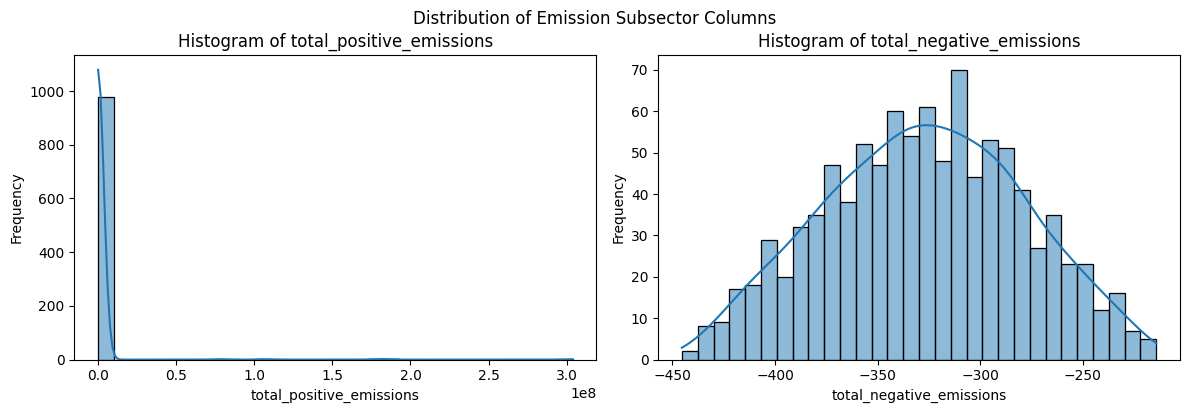

In [11]:
edau.plot_multiple_histograms(training_df, emission_cols, title="Distribution of Emission Subsector Columns")


In [12]:
edau.get_target_var_corr(training_df, "total_positive_emissions")


Correlation with target variable 'total_positive_emissions' (threshold: 0.1):
--------------------------------------------------
total_positive_emissions       : 1.0000



In [13]:
edau.get_target_var_corr(training_df, "total_negative_emissions")


Correlation with target variable 'total_negative_emissions' (threshold: 0.1):
--------------------------------------------------
total_negative_emissions       : 1.0000
group_4_demscalar_ippu         : 0.6411



In [14]:
# Find constant / near-constant cols
const_cols = edau.find_constant_columns(training_df)
near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
print("Constant:", const_cols)
print("Near-constant:", near_const_cols)

Constant: []
Near-constant: []


In [15]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'total_positive_emissions': 0.6097560975609756}


## Data Cleaning

In [16]:
dcu = DataCleaningUtils()

In [17]:
training_df.shape

(984, 48)

In [18]:
training_df_cleaned = dcu.remove_outliers(training_df)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape after removing outliers: (978, 48)


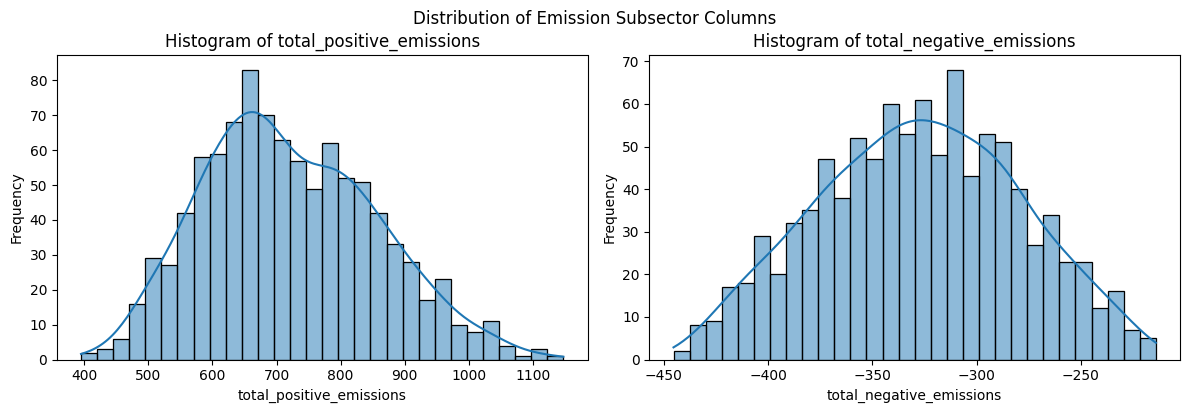

In [19]:
edau.plot_multiple_histograms(training_df_cleaned, emission_cols, title="Distribution of Emission Subsector Columns")

In [20]:
outliers = edau.find_outlier_columns(training_df_cleaned, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'total_positive_emissions': 0.10224948875255625}


In [21]:
edau.get_target_var_corr(training_df_cleaned, "total_positive_emissions")
edau.get_target_var_corr(training_df_cleaned, "total_negative_emissions")


Correlation with target variable 'total_positive_emissions' (threshold: 0.1):
--------------------------------------------------
total_positive_emissions       : 1.0000
group_34_nemomod_en            : 0.8020
group_26_frac_inen_energy      : 0.3198
group_17_frac_trns_fuelmix     : 0.2470
group_8_frac_fgtv              : 0.1764
group_5_efficfactor_enfu_industrial_energy_fuel : 0.1392
total_negative_emissions       : 0.1257
group_47_scalar_scoe_heat_energy_demand : 0.1111
group_46_scalar_scoe_appliance_energy_demand : 0.1055


Correlation with target variable 'total_negative_emissions' (threshold: 0.1):
--------------------------------------------------
total_negative_emissions       : 1.0000
group_4_demscalar_ippu         : 0.6428
total_positive_emissions       : 0.1257



In [35]:
# Calculate correlation between total_positive_emissions and total_negative_emissions
targets_corr = training_df_cleaned["total_positive_emissions"].corr(training_df_cleaned["total_negative_emissions"])
print(f"Correlation between total_positive_emissions and total_negative_emissions: {targets_corr:.4f}") 

Correlation between total_positive_emissions and total_negative_emissions: -0.1257


In [22]:
training_df_cleaned[emission_cols].describe()

,total_positive_emissions,total_negative_emissions
count,978.000000,978.000000
mean,721.182847,-327.699315
std,134.597539,48.435813
min,394.675852,-445.411052
25%,622.536532,-362.957584
50%,704.792756,-327.202508
75%,813.904083,-292.538997
max,1147.970543,-214.071578


## ML

In [28]:
negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]

In [39]:
negative_epp = EmissionsPredictionPipeline(
    df=negative_emissions_df,
    target="total_negative_emissions",
    test_size=0.2,
    random_state=42,
)

negative_epp.run(tune=False, log_transform=False, create_plots=False)

XGB             → MAE: 37.3436, RMSE: 43.5152, R²: 0.2094, SMAPE: 11.6%
MeanBaseline    → MAE: 39.8725, RMSE: 48.9412, R²: -0.0001, SMAPE: 12.3%
MedianBaseline  → MAE: 39.9169, RMSE: 48.9463, R²: -0.0003, SMAPE: 12.3%
RandomForest    → MAE: 35.2817, RMSE: 40.0911, R²: 0.3289, SMAPE: 10.9%
ElasticNet      → MAE: 37.7584, RMSE: 46.3831, R²: 0.1017, SMAPE: 11.7%

=== CV Results for XGB ===
test_MAE: 33.6913 ± 2.2723
test_R2: 0.2881 ± 0.0797
test_RMSE: 40.2677 ± 2.2873

=== CV Results for MeanBaseline ===
test_MAE: 39.7697 ± 3.5370
test_R2: -0.0128 ± 0.0121
test_RMSE: 48.2511 ± 3.7051

=== CV Results for MedianBaseline ===
test_MAE: 39.7772 ± 3.5404
test_R2: -0.0119 ± 0.0074
test_RMSE: 48.2309 ± 3.6995

=== CV Results for RandomForest ===
test_MAE: 32.4116 ± 1.1192
test_R2: 0.3693 ± 0.0791
test_RMSE: 37.8292 ± 0.9999

=== CV Results for ElasticNet ===
test_MAE: 37.6531 ± 3.4593
test_R2: 0.0960 ± 0.0142
test_RMSE: 45.5900 ± 3.5591


In [33]:
positive_epp = EmissionsPredictionPipeline(
    df=positive_emissions_df,
    target="total_positive_emissions",
    test_size=0.2,
    random_state=42,
)
positive_epp.run(tune=False, log_transform=False, create_plots=False)

XGB             → MAE: 41.1674, RMSE: 51.9757, R²: 0.8536, SMAPE: 5.7%
MeanBaseline    → MAE: 114.7639, RMSE: 136.2195, R²: -0.0058, SMAPE: 16.0%
MedianBaseline  → MAE: 112.7956, RMSE: 135.8350, R²: -0.0001, SMAPE: 15.8%
RandomForest    → MAE: 40.9850, RMSE: 50.7722, R²: 0.8603, SMAPE: 5.7%
ElasticNet      → MAE: 100.6945, RMSE: 119.6250, R²: 0.2244, SMAPE: 14.1%

=== CV Results for XGB ===
test_MAE: 43.1724 ± 1.9745
test_R2: 0.8313 ± 0.0136
test_RMSE: 54.8529 ± 2.4300

=== CV Results for MeanBaseline ===
test_MAE: 109.8662 ± 4.0329
test_R2: -0.0084 ± 0.0048
test_RMSE: 134.2568 ± 4.0263

=== CV Results for MedianBaseline ===
test_MAE: 109.6332 ± 4.4256
test_R2: -0.0198 ± 0.0197
test_RMSE: 135.0163 ± 4.4752

=== CV Results for RandomForest ===
test_MAE: 44.6853 ± 1.5774
test_R2: 0.8202 ± 0.0161
test_RMSE: 56.5777 ± 1.4999

=== CV Results for ElasticNet ===
test_MAE: 96.0563 ± 3.4886
test_R2: 0.2233 ± 0.0073
test_RMSE: 117.8299 ± 3.5476



=== XGB ===
total_positive_emissions       → MAE: 41.1674, RMSE: 51.9757, R²: 0.8536, SMAPE: 5.7%
total_negative_emissions       → MAE: 37.3436, RMSE: 43.5152, R²: 0.2094, SMAPE: 11.6%

=== MeanBaseline ===
total_positive_emissions       → MAE: 114.7639, RMSE: 136.2195, R²: -0.0058, SMAPE: 16.0%
total_negative_emissions       → MAE: 39.8725, RMSE: 48.9412, R²: -0.0001, SMAPE: 12.3%

=== MedianBaseline ===
total_positive_emissions       → MAE: 112.7956, RMSE: 135.8350, R²: -0.0001, SMAPE: 15.8%
total_negative_emissions       → MAE: 39.9169, RMSE: 48.9463, R²: -0.0003, SMAPE: 12.3%

=== RandomForest ===
total_positive_emissions       → MAE: 42.4060, RMSE: 52.5138, R²: 0.8505, SMAPE: 6.0%
total_negative_emissions       → MAE: 34.3200, RMSE: 40.8740, R²: 0.3024, SMAPE: 10.6%

=== ElasticNet ===
total_positive_emissions       → MAE: 100.6945, RMSE: 119.6250, R²: 0.2244, SMAPE: 14.1%
total_negative_emissions       → MAE: 37.7584, RMSE: 46.3831, R²: 0.1017, SMAPE: 11.7%

=== CV Results for X

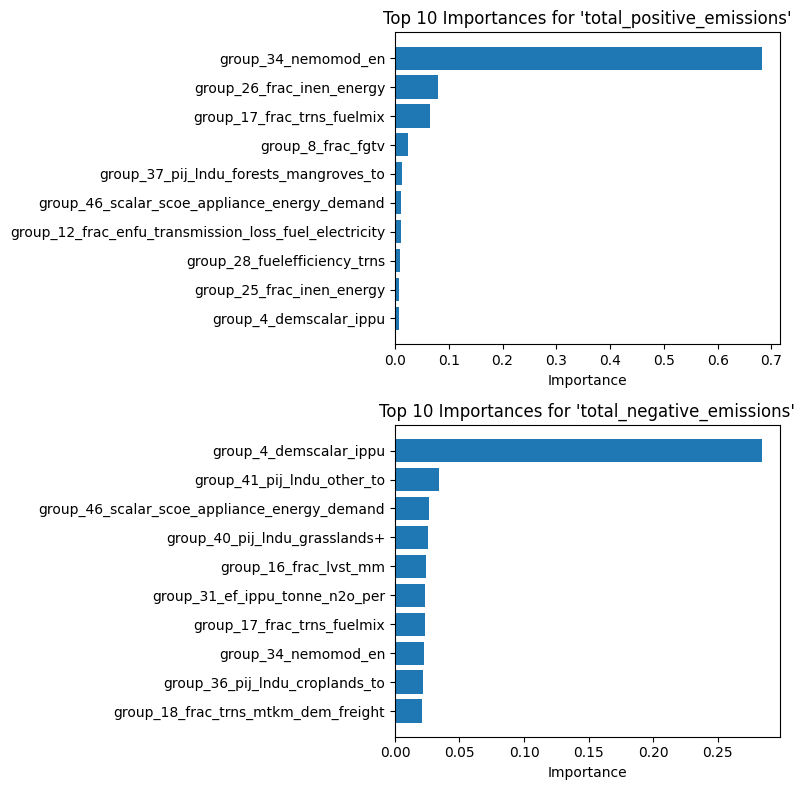

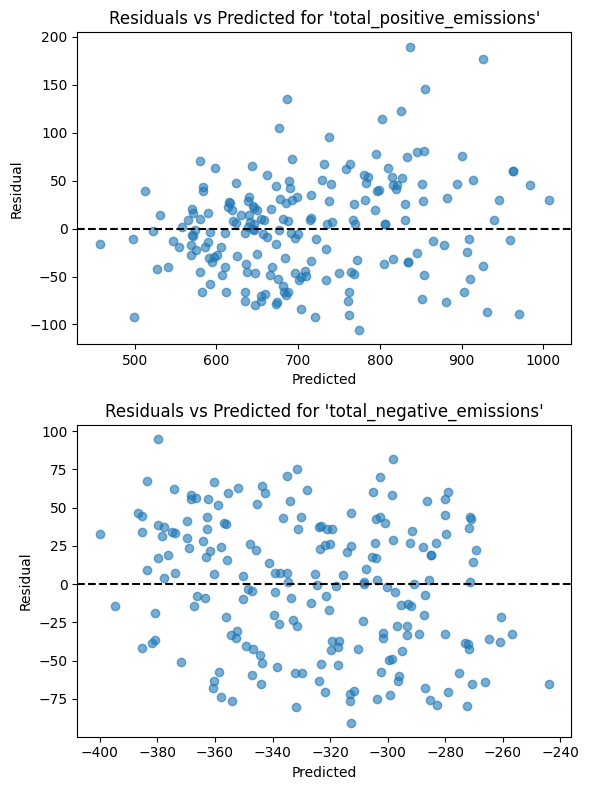

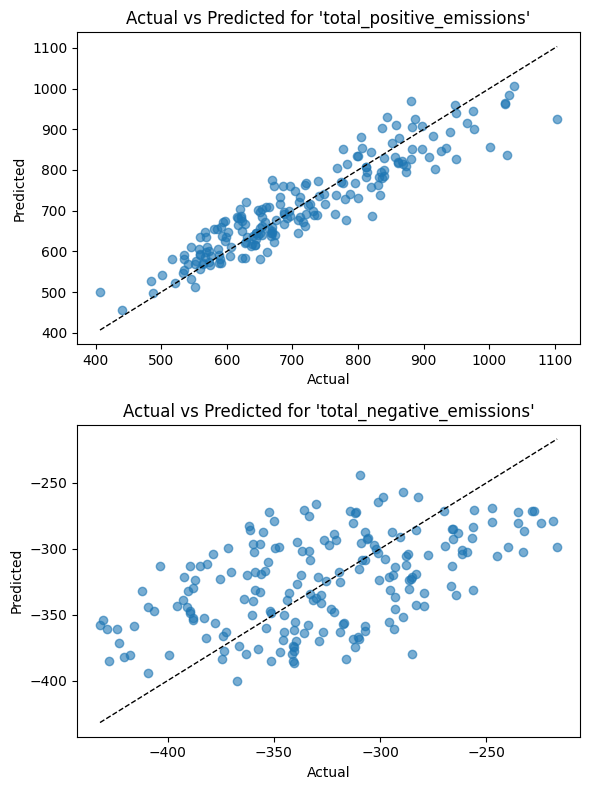

In [42]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=["total_positive_emissions","total_negative_emissions"])
mulp.run(tune=False, log_transform=False, plot_figures=True)